# DATASCI207 Group Project

## Imports

In [ ]:
import os
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import matplotlib.dates as mdates

from sklearn.model_selection import train_test_split
from sklearn.linear_model import Ridge  # more stable than OLS here
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import accuracy_score
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.metrics import r2_score
from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_error
from sklearn.preprocessing import StandardScaler

import tensorflow as tf
from tensorflow.keras.layers import GRU
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import InputLayer, LSTM, Dense
from tensorflow.keras.callbacks import ModelCheckpoint
from tensorflow.keras.losses import MeanSquaredError
from tensorflow.keras.metrics import RootMeanSquaredError
from tensorflow.keras.optimizers import Adam

from hyswap import exceedance, percentiles, plots, rasterhydrograph, utils
from xgboost import XGBRegressor
import seaborn as sns
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.graphics.tsaplots import plot_pacf

## Read and Process Data

In [3]:
raw_data_folder = "/Users/afrahboateng/Documents/DATASCI 207 Applied Machine Learning/Water Project/data/raw"

shape: (558252, 7)


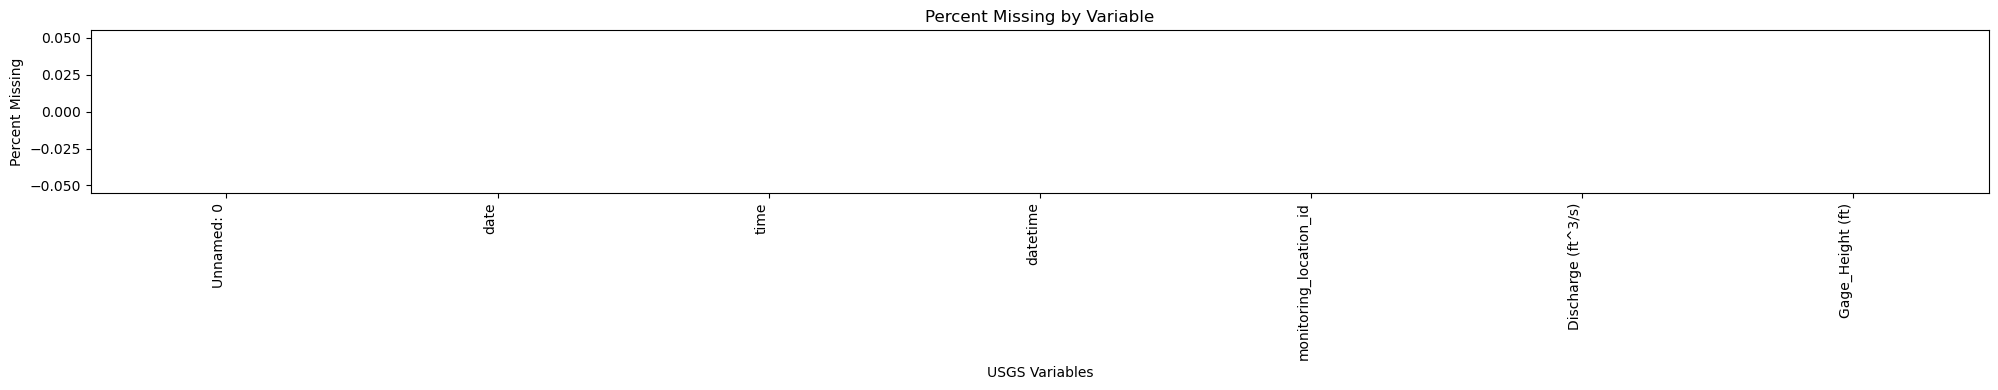

,Unnamed: 0,date,time,datetime,monitoring_location_id,Discharge (ft^3/s),Gage_Height (ft)
0,0,2010-01-01,00:00,2010-01-01 00:00,USGS-01389500,3870.0,5.09
1,1,2010-01-01,00:15,2010-01-01 00:15,USGS-01389500,3870.0,5.09
2,2,2010-01-01,00:30,2010-01-01 00:30,USGS-01389500,3840.0,5.07
3,3,2010-01-01,00:45,2010-01-01 00:45,USGS-01389500,3850.0,5.08
4,4,2010-01-01,01:00,2010-01-01 01:00,USGS-01389500,3850.0,5.08


In [4]:
# -----------------------------
# Initial Examination of USGS Data
# -----------------------------

df_usgs = pd.read_csv(f"{raw_data_folder}/USGS_water_data.csv")
print("shape:", df_usgs.shape)
df_usgs.head(10)

# -----------------------------
# Bar chart of percent missing
# -----------------------------
pct_missing = (df_usgs.isna().mean() * 100).sort_values(ascending=True)

pct_missing.plot(
    kind="bar",
    figsize=(20, 4)
)

plt.xlabel("USGS Variables")
plt.ylabel("Percent Missing")
plt.title("Percent Missing by Variable")

plt.xticks(rotation=90, ha="right")

plt.tight_layout()
plt.show()

df_usgs.head()


In [5]:
# -----------------------
# Cleaning of USGS Data
# -----------------------

df_usgs_v2 = df_usgs.copy()

df_usgs_v2["date"] = pd.to_datetime(df_usgs_v2["date"])
df_usgs_v2["date"]= df_usgs_v2["date"].dt.normalize()
df_usgs_v2 = df_usgs_v2.sort_values("datetime")
df_usgs_v2["datetime"] = pd.to_datetime(df_usgs_v2["datetime"]) # format datetime variable to true datetime
df_usgs_v2 = df_usgs_v2.set_index("datetime") # set the datetime to the index od the dataset
df_usgs_v2 = df_usgs_v2.sort_index() # sort based on the datetime index
df_usgs_v2 = df_usgs_v2.apply(pd.to_numeric, errors="coerce") #make all columns numeric


# RESAMPLE TO HOURLY 
df_usgs_hourly = df_usgs_v2.resample("H").mean() #take the mean
df_usgs_hourly = df_usgs_hourly.interpolate(method="time") # optional but recommended (same as weather)

# Observe
print("USGS hourly shape:", df_usgs_hourly.shape)
df_usgs_hourly.head()

USGS hourly shape: (140233, 6)


/var/folders/mh/q231lbp52ylbpc0xcbwph87h0000gn/T/ipykernel_79682/198486125.py:17: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  df_usgs_hourly = df_usgs_v2.resample("H").mean() #take the mean


,Unnamed: 0,date,time,monitoring_location_id,Discharge (ft^3/s),Gage_Height (ft)
datetime,,,,,,
2010-01-01 00:00:00,1.5,1.262304e+18,NaN,NaN,3857.5,5.0825
2010-01-01 01:00:00,5.5,1.262304e+18,NaN,NaN,3840.0,5.0725
2010-01-01 02:00:00,9.5,1.262304e+18,NaN,NaN,3812.5,5.0525
2010-01-01 03:00:00,13.5,1.262304e+18,NaN,NaN,3792.5,5.0375
2010-01-01 04:00:00,17.5,1.262304e+18,NaN,NaN,3772.5,5.0225


/var/folders/mh/q231lbp52ylbpc0xcbwph87h0000gn/T/ipykernel_79682/1001967971.py:5: DtypeWarning: Columns (21,27,28,29,30,31,32,33,35,36,37,38,42,43,44,49,50,52,53,54,57,59,60,61,65,70,72,73,74,76,77,82,89,90,97,98,99,100,101,102,103,104,105,106,107,108,115,118,120) have mixed types. Specify dtype option on import or set low_memory=False.
  wt = pd.read_csv("local_climate_data.csv")


shape: (117654, 124)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 117654 entries, 0 to 117653
Columns: 124 entries, STATION to WindEquipmentChangeDate
dtypes: float64(56), int64(3), object(65)
memory usage: 111.3+ MB


/var/folders/mh/q231lbp52ylbpc0xcbwph87h0000gn/T/ipykernel_79682/1001967971.py:25: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


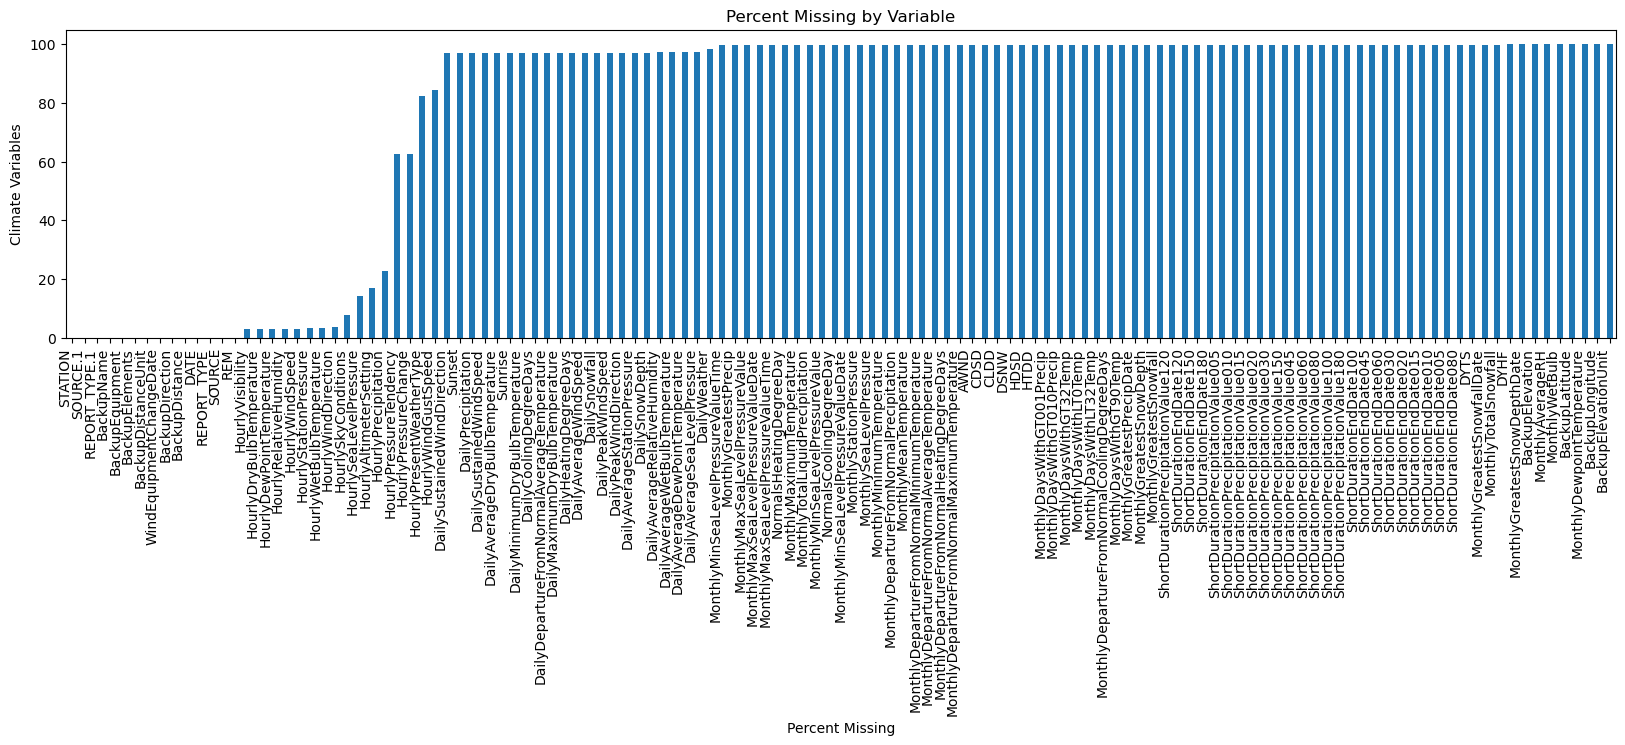

,STATION,DATE,REPORT_TYPE,SOURCE,AWND,BackupDirection,BackupDistance,BackupDistanceUnit,BackupElements,BackupElevation,...,ShortDurationPrecipitationValue045,ShortDurationPrecipitationValue060,ShortDurationPrecipitationValue080,ShortDurationPrecipitationValue100,ShortDurationPrecipitationValue120,ShortDurationPrecipitationValue150,ShortDurationPrecipitationValue180,Sunrise,Sunset,WindEquipmentChangeDate
0,72502014734,2016-01-01T00:51:00,FM-15,7,NaN,SSE,0.75,mi,"TEMP, PRECIP, SNOW",NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2009-07-08
1,72502014734,2016-01-01T01:00:00,FM-12,4,NaN,SSE,0.75,mi,"TEMP, PRECIP, SNOW",NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2009-07-08
2,72502014734,2016-01-01T01:51:00,FM-15,7,NaN,SSE,0.75,mi,"TEMP, PRECIP, SNOW",NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2009-07-08
3,72502014734,2016-01-01T02:51:00,FM-15,7,NaN,SSE,0.75,mi,"TEMP, PRECIP, SNOW",NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2009-07-08
4,72502014734,2016-01-01T03:51:00,FM-15,7,NaN,SSE,0.75,mi,"TEMP, PRECIP, SNOW",NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2009-07-08


In [6]:
# -----------------------------
# Initial Examination of NOAA Data
# -----------------------------

wt = pd.read_csv("local_climate_data.csv")
print("shape:", wt.shape)
wt.info()

# -----------------------------
# Bar chart of percent missing
# -----------------------------
pct_missing = (wt.isna().mean() * 100).sort_values(ascending=True)

pct_missing.plot(
    kind="bar",
    figsize=(20, 4)
)

plt.xlabel("Percent Missing")
plt.ylabel("Climate Variables")
plt.title("Percent Missing by Variable")

plt.xticks(rotation=90, ha="right")

plt.tight_layout()
plt.show()

wt.head()

In [7]:
# Process Climate Data

cols_to_keep = [
    "DATE",
    "HourlyPrecipitation",
    "HourlyDryBulbTemperature",
    "HourlyDewPointTemperature",
    "HourlyRelativeHumidity",
    "HourlyStationPressure",
    "HourlyWindSpeed"
]

wt_clean = wt[cols_to_keep].copy()

wt_clean["DATE"] = pd.to_datetime(wt_clean["DATE"])
wt_clean = wt_clean.set_index("DATE")

for col in wt_clean.columns:
    wt_clean[col] = pd.to_numeric(wt_clean[col], errors="coerce")

# =========================
# RESAMPLE TO HOURLY 
# =========================

wt_hourly = wt_clean.resample("H").mean()
wt_hourly = wt_hourly.interpolate(method="time")

print(wt_hourly.shape)
wt_hourly.head(10)


(84583, 6)


/var/folders/mh/q231lbp52ylbpc0xcbwph87h0000gn/T/ipykernel_79682/1579237635.py:25: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  wt_hourly = wt_clean.resample("H").mean()


,HourlyPrecipitation,HourlyDryBulbTemperature,HourlyDewPointTemperature,HourlyRelativeHumidity,HourlyStationPressure,HourlyWindSpeed
DATE,,,,,,
2016-01-01 00:00:00,0.0,42.0,28.0,58.0,30.04,8.0
2016-01-01 01:00:00,0.0,42.0,29.0,60.0,30.04,9.5
2016-01-01 02:00:00,0.0,41.0,29.0,62.0,30.04,11.0
2016-01-01 03:00:00,0.0,41.0,28.0,60.0,30.04,11.0
2016-01-01 04:00:00,0.0,40.0,28.0,63.0,30.02,14.0
2016-01-01 05:00:00,0.0,40.0,27.0,60.0,30.03,13.0
2016-01-01 06:00:00,0.0,39.0,26.0,60.0,30.04,10.0
2016-01-01 07:00:00,0.0,39.0,26.0,60.0,30.04,9.0
2016-01-01 08:00:00,0.0,39.0,26.0,60.0,30.04,10.0


In [45]:
#Merge USGS and CLimate Data

df_usgs_v2 = df_usgs.copy()
wt_hourly_v2 = wt_hourly.copy()

# ensure sorted
df_usgs_hourly = df_usgs_hourly.sort_index()
wt_hourly_v2   = wt_hourly_v2.sort_index()

# =========================
# MERGE (hourly ↔ hourly)
# =========================

df_combined_v2_raw = df_usgs_hourly.join(wt_hourly_v2, how="inner")

# feature engineering ONCE
df_combined_v2_raw["flow_t-1h"] = df_combined_v2_raw["Discharge (ft^3/s)"].shift(1)
df_combined_v2_raw["rain_t-6h"] = df_combined_v2_raw["HourlyPrecipitation"].shift(6)
df_combined_v2_raw["temp_t-24h"] = df_combined_v2_raw["HourlyDryBulbTemperature"].shift(24)

df_combined_v2_raw["rain_6h_sum"] = df_combined_v2_raw["HourlyPrecipitation"].rolling(6).sum()
df_combined_v2_raw["rain_24h_sum"] = df_combined_v2_raw["HourlyPrecipitation"].rolling(24).sum()
df_combined_v2_raw["flow_24h_avg"] = df_combined_v2_raw["Discharge (ft^3/s)"].rolling(24).mean()

df_combined_v2 = df_combined_v2_raw.copy()

# make sure datetime exists as index
df_combined_v2 = df_combined_v2.sort_index()

# bring index back as a column
df_combined_v2["datetime"] = df_combined_v2.index

print("shape:", df_combined_v2.shape)
print("\nmissing values per column:\n")
print(df_combined_v2.isna().sum().sort_values(ascending=False).head(15))
df_combined_v2.head()


shape: (84583, 19)

missing values per column:

time                         84583
monitoring_location_id       84583
temp_t-24h                      24
flow_24h_avg                    23
rain_24h_sum                    23
rain_t-6h                        6
rain_6h_sum                      5
flow_t-1h                        1
Unnamed: 0                       0
HourlyWindSpeed                  0
HourlyRelativeHumidity           0
HourlyStationPressure            0
date                             0
HourlyDewPointTemperature        0
HourlyDryBulbTemperature         0
dtype: int64


,Unnamed: 0,date,time,monitoring_location_id,Discharge (ft^3/s),Gage_Height (ft),HourlyPrecipitation,HourlyDryBulbTemperature,HourlyDewPointTemperature,HourlyRelativeHumidity,HourlyStationPressure,HourlyWindSpeed,flow_t-1h,rain_t-6h,temp_t-24h,rain_6h_sum,rain_24h_sum,flow_24h_avg,datetime
2016-01-01 00:00:00,208407.0,1.451606e+18,NaN,NaN,1600.0,3.060,0.0,42.0,28.0,58.0,30.04,8.0,NaN,NaN,NaN,NaN,NaN,NaN,2016-01-01 00:00:00
2016-01-01 01:00:00,208411.5,1.451606e+18,NaN,NaN,1600.0,3.060,0.0,42.0,29.0,60.0,30.04,9.5,1600.0,NaN,NaN,NaN,NaN,NaN,2016-01-01 01:00:00
2016-01-01 02:00:00,208415.5,1.451606e+18,NaN,NaN,1600.0,3.060,0.0,41.0,29.0,62.0,30.04,11.0,1600.0,NaN,NaN,NaN,NaN,NaN,2016-01-01 02:00:00
2016-01-01 03:00:00,208419.5,1.451606e+18,NaN,NaN,1600.0,3.060,0.0,41.0,28.0,60.0,30.04,11.0,1600.0,NaN,NaN,NaN,NaN,NaN,2016-01-01 03:00:00
2016-01-01 04:00:00,208423.5,1.451606e+18,NaN,NaN,1595.0,3.055,0.0,40.0,28.0,63.0,30.02,14.0,1600.0,NaN,NaN,NaN,NaN,NaN,2016-01-01 04:00:00


## EDA

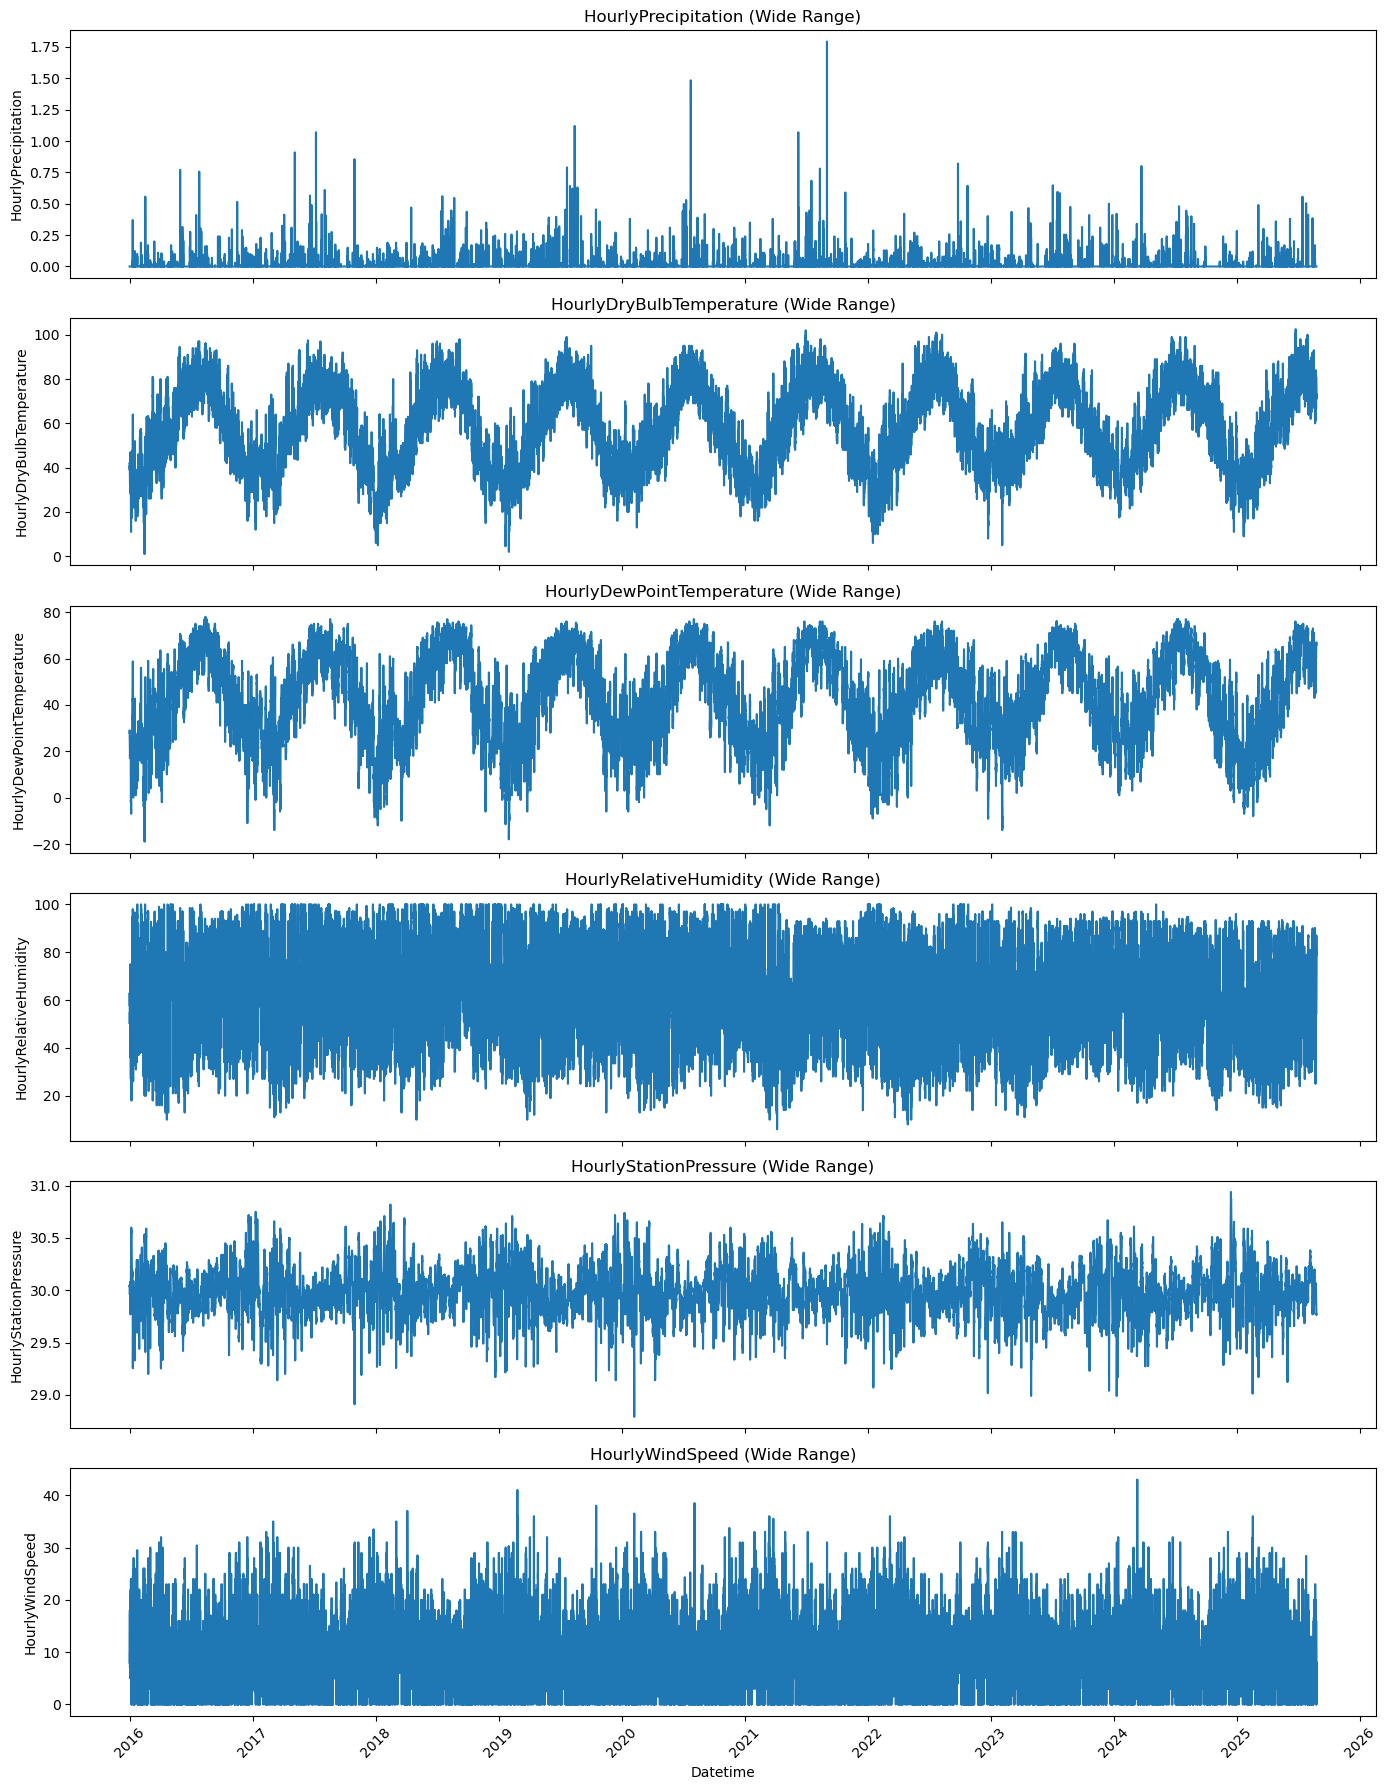

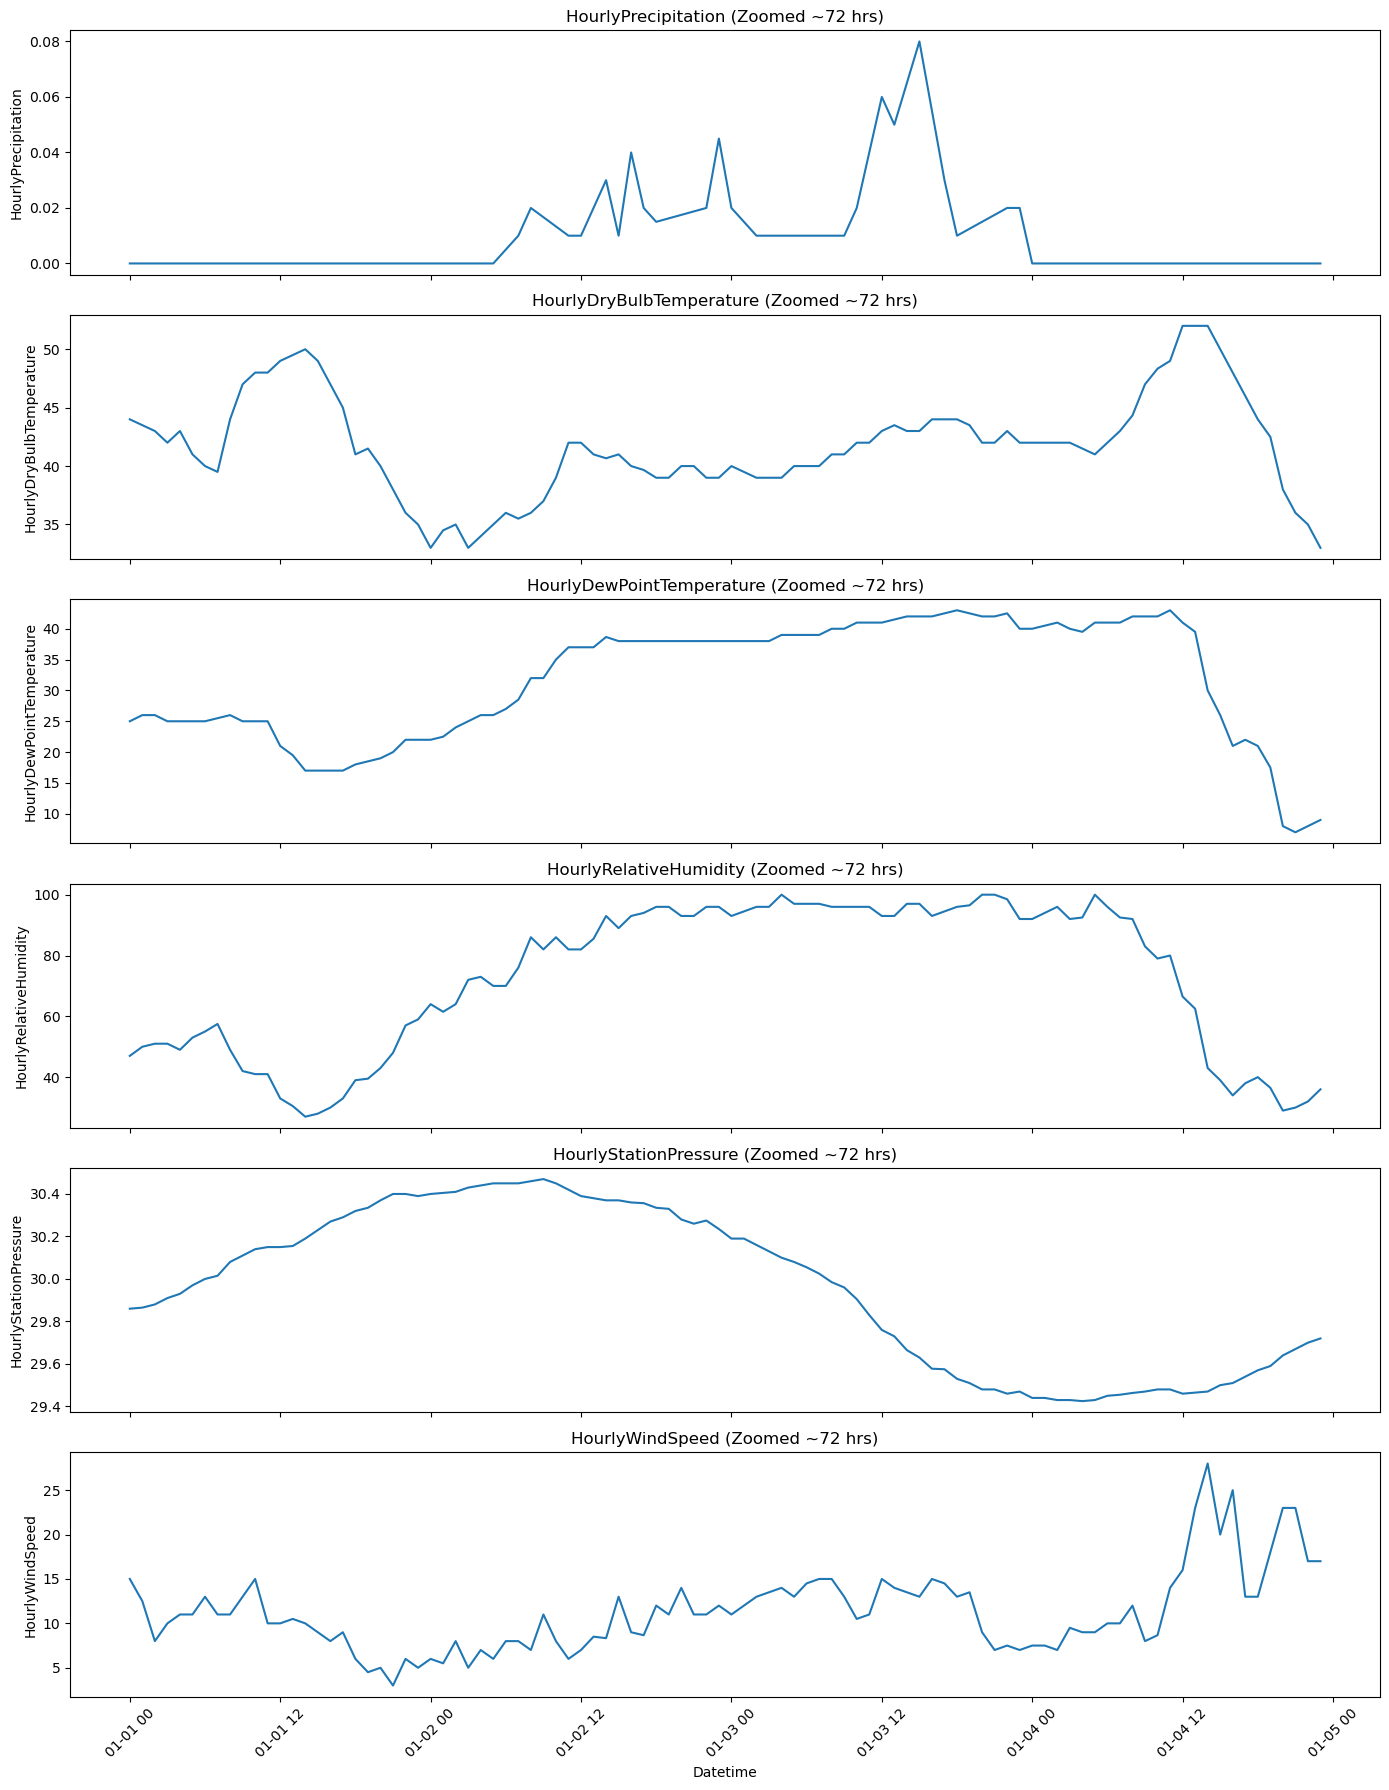

In [8]:
weather_cols = [
    "HourlyPrecipitation",
    "HourlyDryBulbTemperature",
    "HourlyDewPointTemperature",
    "HourlyRelativeHumidity",
    "HourlyStationPressure",
    "HourlyWindSpeed"
]

# =========================
# USER INPUT
# =========================

# Wide range (e.g. months / year)
start_wide = "2010-01-01"
end_wide   = "2026-06-01"

# Zoomed range (~3 days)
start_zoom = "2017-01-01"
end_zoom   = "2017-01-04"

#Filter Data
df_wide = df_combined_v2.loc[start_wide:end_wide]
df_zoom = df_combined_v2.loc[start_zoom:end_zoom]

# Plot Wide Range

import matplotlib.pyplot as plt

fig, axes = plt.subplots(len(weather_cols), 1, figsize=(14, 3*len(weather_cols)), sharex=True)

for i, col in enumerate(weather_cols):
    axes[i].plot(df_wide.index, df_wide[col])
    axes[i].set_title(f"{col} (Wide Range)")
    axes[i].set_ylabel(col)

plt.xlabel("Datetime")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Plot Zoomed In

fig, axes = plt.subplots(len(weather_cols), 1, figsize=(14, 3*len(weather_cols)), sharex=True)

for i, col in enumerate(weather_cols):
    axes[i].plot(df_zoom.index, df_zoom[col])
    axes[i].set_title(f"{col} (Zoomed ~72 hrs)")
    axes[i].set_ylabel(col)

plt.xlabel("Datetime")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### EDA of USGS Features

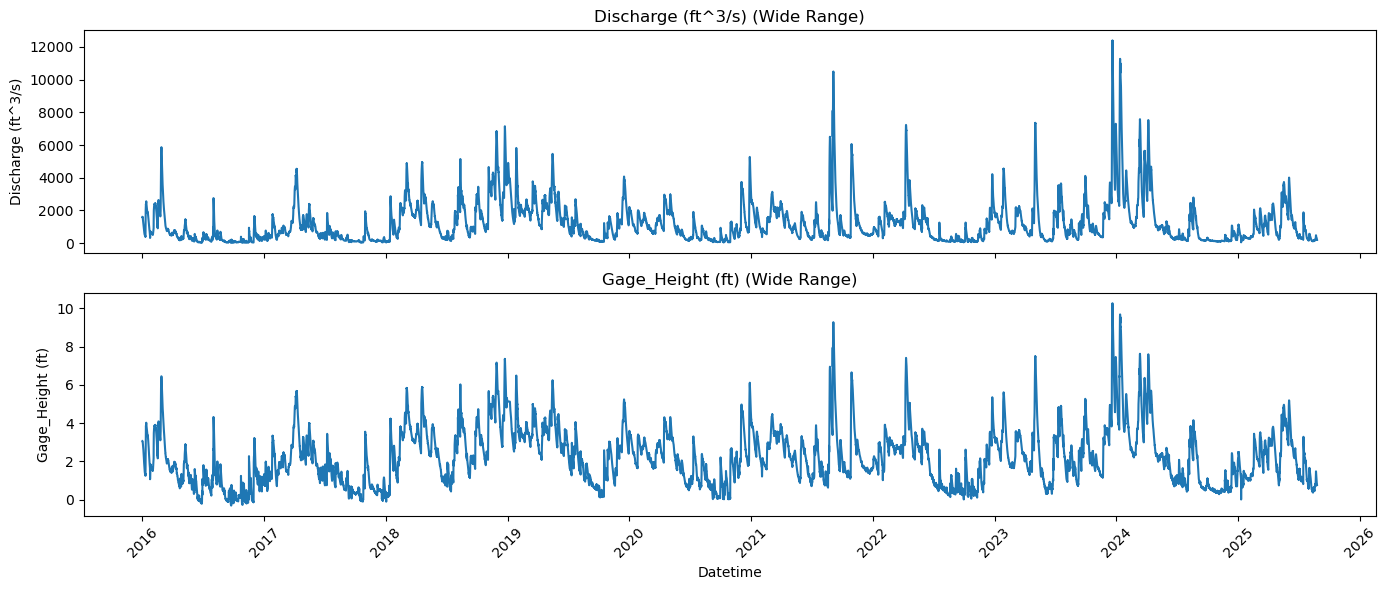

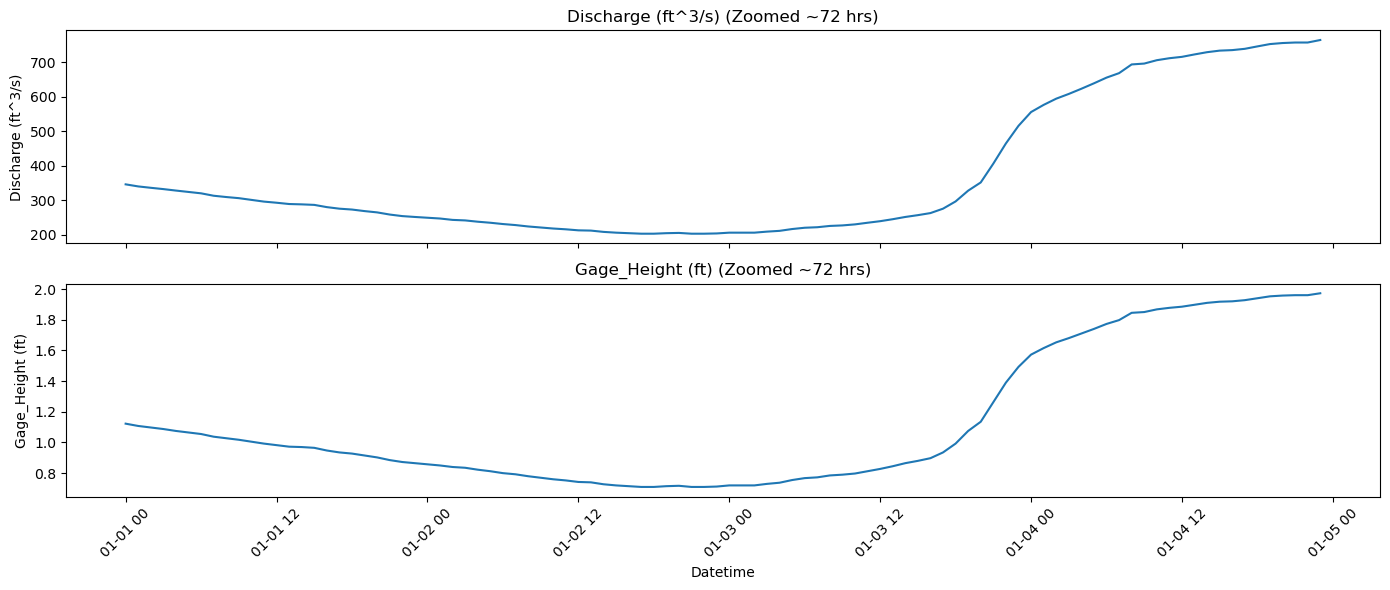

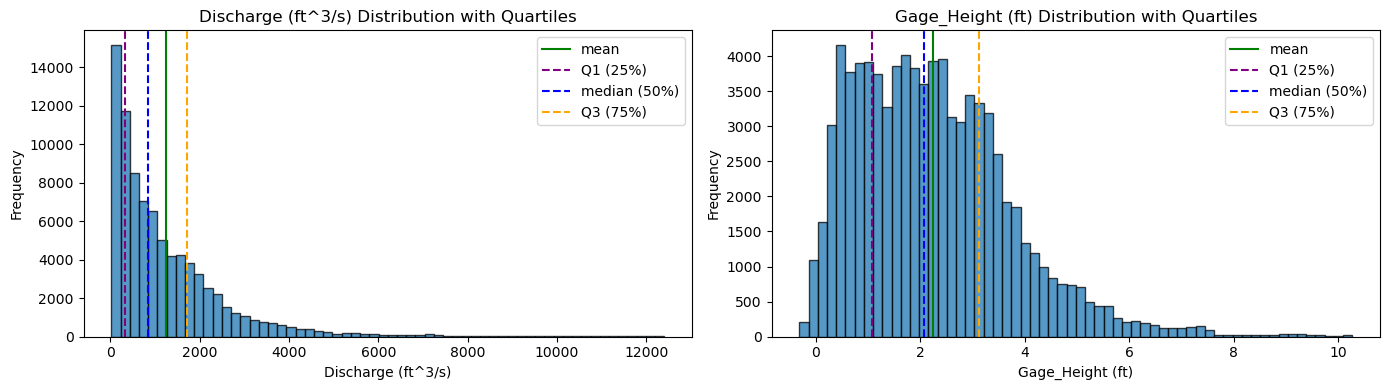

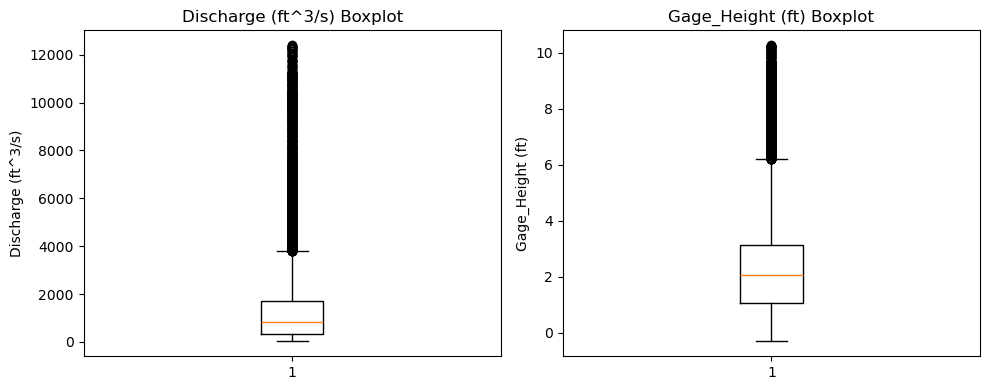

In [9]:
usgs_cols = [
    "Discharge (ft^3/s)",
    "Gage_Height (ft)"
]

# Set dates
start_wide = "2010-01-01"
end_wide   = "2026-06-01"

start_zoom = "2017-01-01"
end_zoom   = "2017-01-04"

df_wide = df_combined_v2.loc[start_wide:end_wide]
df_zoom = df_combined_v2.loc[start_zoom:end_zoom]

# Wide range plots
fig, axes = plt.subplots(len(usgs_cols), 1, figsize=(14, 3*len(usgs_cols)), sharex=True)

for i, col in enumerate(usgs_cols):
    axes[i].plot(df_wide.index, df_wide[col])
    axes[i].set_title(f"{col} (Wide Range)")
    axes[i].set_ylabel(col)

plt.xlabel("Datetime")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

#Zoomed in Plots
fig, axes = plt.subplots(len(usgs_cols), 1, figsize=(14, 3*len(usgs_cols)), sharex=True)

for i, col in enumerate(usgs_cols):
    axes[i].plot(df_zoom.index, df_zoom[col])
    axes[i].set_title(f"{col} (Zoomed ~72 hrs)")
    axes[i].set_ylabel(col)

plt.xlabel("Datetime")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

#Histogram
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

for i, col in enumerate(usgs_cols):
    
    data = df_combined_v2[col].dropna()
    
    axes[i].hist(data, bins=60, edgecolor="black", alpha=0.75)
    
    # -------------------------
    # Summary statistics
    # -------------------------
    mean_val = data.mean()
    q1 = data.quantile(0.25)
    q2 = data.quantile(0.50)  # median
    q3 = data.quantile(0.75)
    
    # -------------------------
    # Vertical lines
    # -------------------------
    axes[i].axvline(mean_val, color="green", linestyle="-", label="mean")
    axes[i].axvline(q1, color="purple", linestyle="--", label="Q1 (25%)")
    axes[i].axvline(q2, color="blue", linestyle="--", label="median (50%)")
    axes[i].axvline(q3, color="orange", linestyle="--", label="Q3 (75%)")
    
    axes[i].set_title(f"{col} Distribution with Quartiles")
    axes[i].set_xlabel(col)
    axes[i].set_ylabel("Frequency")
    axes[i].legend()

plt.tight_layout()
plt.show()

# Box Plots
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

for i, col in enumerate(usgs_cols):
    data = df_combined_v2[col].dropna()
    axes[i].boxplot(data, vert=True, showfliers=True)
    axes[i].set_title(f"{col} Boxplot")
    axes[i].set_ylabel(col)

plt.tight_layout()
plt.show()

### Correlation Analysis

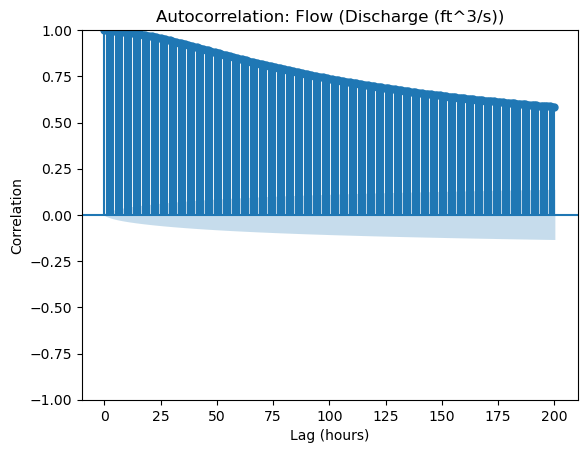

In [11]:
flow = df_combined_v2["Discharge (ft^3/s)"].iloc[:50000]

plot_acf(flow, lags=200)

plt.xlabel("Lag (hours)")
plt.ylabel("Correlation")
plt.title("Autocorrelation: Flow (Discharge (ft^3/s))")
plt.show()

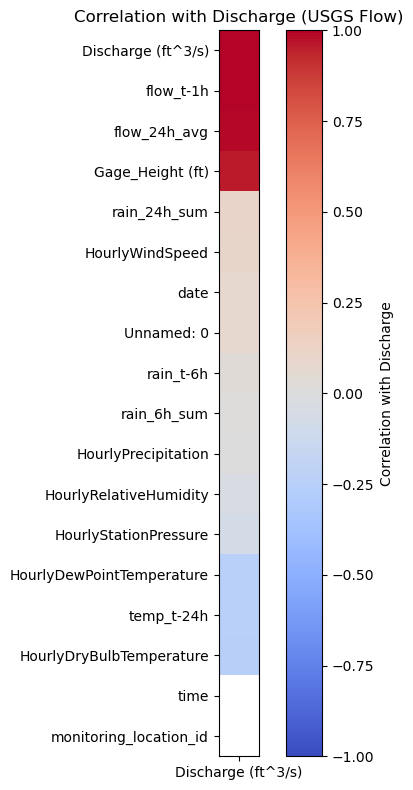

In [12]:
# -----------------------------
# Full correlation matrix
# -----------------------------
corr_matrix = df_combined_v2.corr(numeric_only=True)

# -----------------------------
# Focus only on Discharge relationships
# -----------------------------
corr_discharge = corr_matrix[["Discharge (ft^3/s)"]].sort_values(
    by="Discharge (ft^3/s)",
    ascending=False
)

# -----------------------------
# Heatmap
# -----------------------------
plt.figure(figsize=(6, 8))

plt.imshow(corr_discharge, cmap="coolwarm", vmin=-1, vmax=1)

plt.colorbar(label="Correlation with Discharge")

plt.yticks(
    range(len(corr_discharge.index)),
    corr_discharge.index
)

plt.xticks([0], ["Discharge (ft^3/s)"], rotation=0)

plt.title("Correlation with Discharge (USGS Flow)")

plt.tight_layout()
plt.show()

## Baseline Model: Persistence (Lagged Forecast)

=== Baseline Persistence Model ===
Lag: 24
MSE : 85913.1293
RMSE: 293.1094
MAE : 167.3345


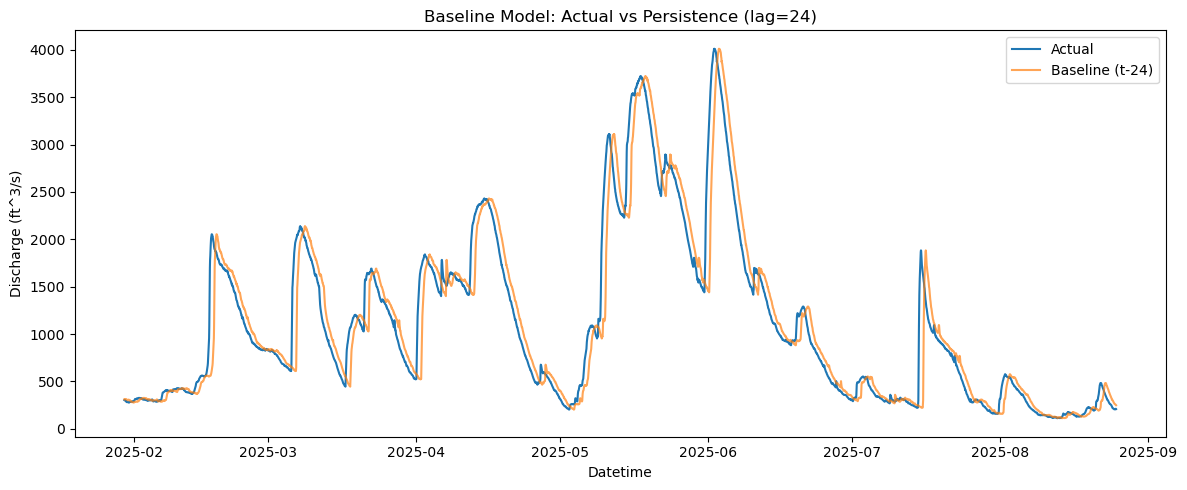

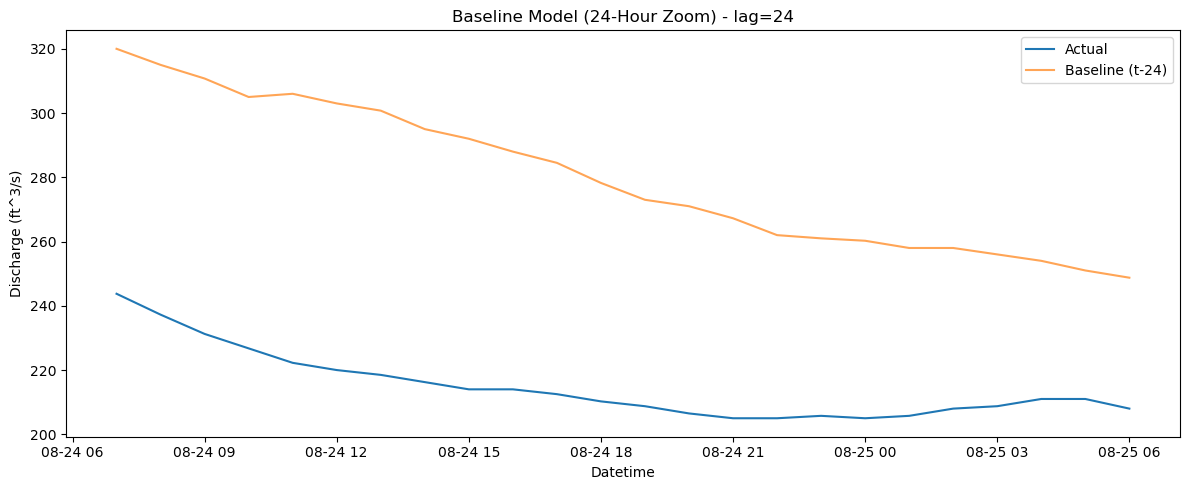

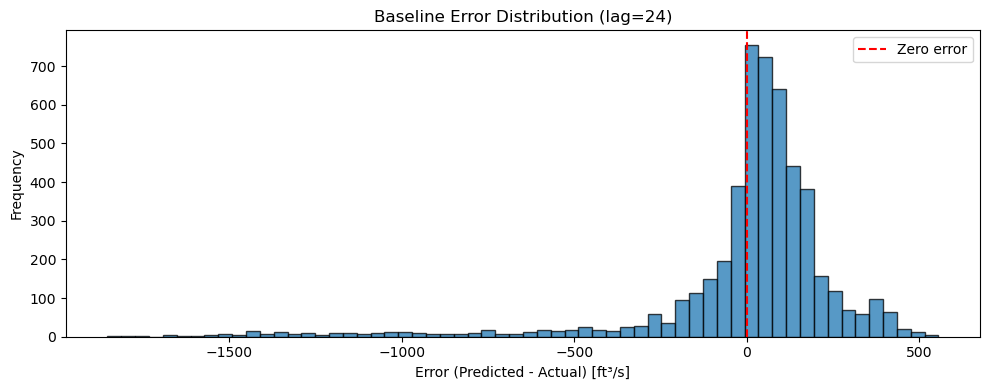

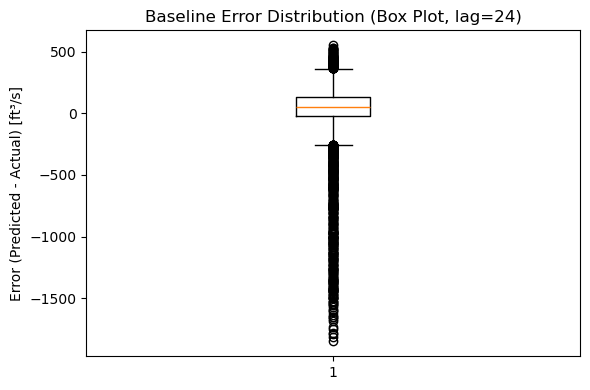

In [84]:
# =========================
# USER CONTROLS
# =========================
lag = 24                  # try 1, 3, 6, 24, etc.
n_rows = 5000             # fallback window
start_date = None        # e.g. "2024-01-01"
end_date = None          # e.g. "2024-06-01"

col = "Discharge (ft^3/s)"

# =========================
# LOAD + SORT
# =========================
df = df_combined_v2.copy()
df = df.sort_index()

y = df[col]

# =========================
# WINDOW SELECTION
# =========================
if start_date is not None and end_date is not None:
    y = y.loc[start_date:end_date]
else:
    y = y.tail(n_rows)

# =========================
# BASELINE PREDICTION
# y_hat[t] = y[t - lag]
# =========================
y_true = y.iloc[lag:]
y_pred = y.shift(lag).iloc[lag:]

# align
mask = y_true.notna() & y_pred.notna()
y_true = y_true[mask]
y_pred = y_pred[mask]

# =========================
# METRICS
# =========================
mse = mean_squared_error(y_true, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_true, y_pred)

print("=== Baseline Persistence Model ===")
print(f"Lag: {lag}")
print(f"MSE : {mse:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"MAE : {mae:.4f}")

# =========================
# FULL PLOT
# =========================
plt.figure(figsize=(12,5))
plt.plot(y_true.index, y_true.values, label="Actual")
plt.plot(y_pred.index, y_pred.values, label=f"Baseline (t-{lag})", alpha=0.7)

plt.title(f"Baseline Model: Actual vs Persistence (lag={lag})")
plt.xlabel("Datetime")
plt.ylabel("Discharge (ft^3/s)")
plt.legend()
plt.tight_layout()
plt.show()

# =========================
# 24-HOUR ZOOM PLOT
# =========================

zoom_hours = 24

# take last chunk for visualization
y_true_zoom = y_true.tail(zoom_hours)
y_pred_zoom = y_pred.tail(zoom_hours)

plt.figure(figsize=(12,5))
plt.plot(y_true_zoom.index, y_true_zoom.values, label="Actual")
plt.plot(y_pred_zoom.index, y_pred_zoom.values, label=f"Baseline (t-{lag})", alpha=0.7)

plt.title(f"Baseline Model (24-Hour Zoom) - lag={lag}")
plt.xlabel("Datetime")
plt.ylabel("Discharge (ft^3/s)")
plt.legend()
plt.tight_layout()
plt.show()

# =========================
# ERROR COMPUTATION
# =========================
errors = y_pred - y_true
abs_errors = errors.abs()

# =========================
# ERROR DISTRIBUTION (SIGNED)
# =========================
plt.figure(figsize=(10,4))

plt.hist(errors, bins=60, edgecolor="black", alpha=0.75)

plt.axvline(0, color="red", linestyle="--", label="Zero error")

plt.title(f"Baseline Error Distribution (lag={lag})")
plt.xlabel("Error (Predicted - Actual) [ft³/s]")
plt.ylabel("Frequency")
plt.legend()

plt.tight_layout()
plt.show()

# Boxplot of Errors

plt.figure(figsize=(6,4))

plt.boxplot(errors.dropna(), vert=True)

plt.title(f"Baseline Error Distribution (Box Plot, lag={lag})")
plt.ylabel("Error (Predicted - Actual) [ft³/s]")

plt.tight_layout()
plt.show()


# Single Variable LSTM

In [46]:

def df_to_X_y(df, window_size=5,  horizon=1):
  # Creates our X input vector and our y output vector
  # from a df when given the window size and horizon

  # window size 5 horizon = 1:
  # X: [1,2,3,4,5] --> y:6
  # X: [2,3,4,5,6] --> y:y

  # window size 5 and horizon = 3:
  # X: [1,2,3,4,5] → y: 8
  # X: [2,3,4,5,6] → y: 9
    df_as_np = df.to_numpy()
    X = []
    y = []
    
    for i in range(len(df_as_np) - window_size - horizon + 1):
        # input window
        row = [[a] for a in df_as_np[i:i+window_size]]
        X.append(row)
        
        # future target
        label = df_as_np[i + window_size + horizon - 1]
        y.append(label)
        
    return np.array(X), np.array(y)

In [47]:
n_rows = 5000  # adjust this freely

target_col = "Discharge (ft^3/s)"

flow = df_combined_v2[target_col]

flow_mini = flow.tail(n_rows).copy()

WINDOW_SIZE = 24
HORIZON = 3

X1_mini, y1_mini = df_to_X_y(flow_mini, WINDOW_SIZE, HORIZON)

print("Mini dataset shapes:", X1_mini.shape, y1_mini.shape)

train_end = int(0.6 * len(X1_mini))
val_end = int(0.8 * len(X1_mini))

X_train1, y_train1 = X1_mini[:train_end], y1_mini[:train_end]
X_val1, y_val1 = X1_mini[train_end:val_end], y1_mini[train_end:val_end]
X_test1, y_test1 = X1_mini[val_end:], y1_mini[val_end:]

print("Train:", X_train1.shape, y_train1.shape)
print("Val:", X_val1.shape, y_val1.shape)
print("Test:", X_test1.shape, y_test1.shape)

Mini dataset shapes: (4974, 24, 1) (4974,)
Train: (2984, 24, 1) (2984,)
Val: (995, 24, 1) (995,)
Test: (995, 24, 1) (995,)


In [48]:
# Rescaling

X_train1 = np.asarray(X_train1, dtype=np.float32)
X_val1   = np.asarray(X_val1, dtype=np.float32)

y_train1 = np.asarray(y_train1, dtype=np.float32)
y_val1   = np.asarray(y_val1, dtype=np.float32)

# ONLY if needed (safe guard)
if len(X_train1.shape) == 2:
    X_train1 = X_train1.reshape(X_train1.shape[0], X_train1.shape[1], 1)
    X_val1   = X_val1.reshape(X_val1.shape[0], X_val1.shape[1], 1)

# y must be 2D
y_train1 = y_train1.reshape(-1, 1)
y_val1   = y_val1.reshape(-1, 1)

x_scaler = StandardScaler()
y_scaler = StandardScaler()

# ---- FIT ONLY ON TRAIN ----
x_scaler.fit(X_train1.reshape(-1, 1))
y_scaler.fit(y_train1)

# ---- TRANSFORM X ----
X_train1 = x_scaler.transform(X_train1.reshape(-1, 1)).reshape(X_train1.shape)
X_val1   = x_scaler.transform(X_val1.reshape(-1, 1)).reshape(X_val1.shape)

# ---- TRANSFORM y ----
y_train1 = y_scaler.transform(y_train1)
y_val1   = y_scaler.transform(y_val1)

print("X_train1:", X_train1.shape)
print("y_train1:", y_train1.shape)

assert len(X_train1.shape) == 3, "X must be 3D for LSTM"
assert len(y_train1.shape) == 2, "y must be 2D"

X_train1: (2984, 24, 1)
y_train1: (2984, 1)


In [49]:
tf.config.threading.set_intra_op_parallelism_threads(2)
tf.config.threading.set_inter_op_parallelism_threads(2)

model1 = Sequential()
model1.add(InputLayer((5, 1)))
model1.add(LSTM(64))
model1.add(Dense(8, 'relu'))
model1.add(Dense(1, 'linear'))

model1.summary()

Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_3 (LSTM)                   │ (None, 64)             │        16,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 8)              │           520 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 17,425 (68.07 KB)

 Trainable params: 17,425 (68.07 KB)

 Non-trainable params: 0 (0.00 B)

In [50]:
cp1 = ModelCheckpoint('model1.keras', save_best_only=True)

model1.compile(
    loss=MeanSquaredError(),
    optimizer=Adam(learning_rate=0.0001),
    metrics=[RootMeanSquaredError()]
)

Epoch 1/10
94/94 - 3s - 32ms/step - loss: 0.4607 - root_mean_squared_error: 0.6788 - val_loss: 0.0593 - val_root_mean_squared_error: 0.2434
Epoch 2/10
94/94 - 1s - 14ms/step - loss: 0.0658 - root_mean_squared_error: 0.2565 - val_loss: 0.0153 - val_root_mean_squared_error: 0.1235
Epoch 3/10
94/94 - 1s - 13ms/step - loss: 0.0408 - root_mean_squared_error: 0.2020 - val_loss: 0.0115 - val_root_mean_squared_error: 0.1071
Epoch 4/10
94/94 - 2s - 17ms/step - loss: 0.0329 - root_mean_squared_error: 0.1813 - val_loss: 0.0101 - val_root_mean_squared_error: 0.1007
Epoch 5/10
94/94 - 1s - 14ms/step - loss: 0.0276 - root_mean_squared_error: 0.1663 - val_loss: 0.0079 - val_root_mean_squared_error: 0.0889
Epoch 6/10
94/94 - 1s - 14ms/step - loss: 0.0238 - root_mean_squared_error: 0.1543 - val_loss: 0.0069 - val_root_mean_squared_error: 0.0831
Epoch 7/10
94/94 - 1s - 15ms/step - loss: 0.0208 - root_mean_squared_error: 0.1442 - val_loss: 0.0059 - val_root_mean_squared_error: 0.0771
Epoch 8/10
94/94 - 1

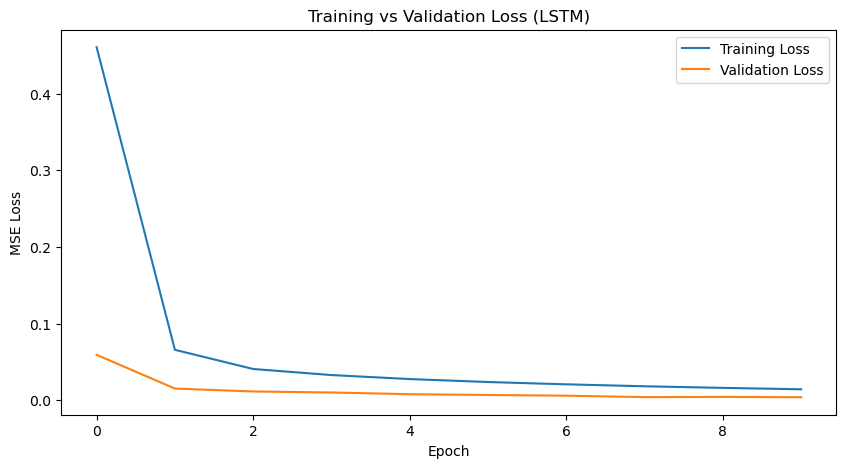

In [51]:
history = model1.fit(
    X_train1,
    y_train1,
    validation_data=(X_val1, y_val1),
    epochs=10,
    callbacks=[cp1],
    verbose=2
)

train_loss = history.history['loss']
val_loss = history.history['val_loss']

plt.figure(figsize=(10,5))
plt.plot(train_loss, label="Training Loss")
plt.plot(val_loss, label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("Training vs Validation Loss (LSTM)")
plt.legend()
plt.show()

In [71]:
train_predictions = model1.predict(X_train1).flatten()
actuals = y_train1.flatten()

train_results = pd.DataFrame({
    "Train Predictions": train_predictions,
    "Actuals": actuals
})

train_results


94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step


,Train Predictions,Actuals
0,-1.181988,-1.200639
1,-1.182102,-1.202283
2,-1.182359,-1.203379
3,-1.182742,-1.206667
4,-1.183315,-1.205571
...,...,...
2979,2.769446,2.592990
2980,2.754323,2.573808
2981,2.739222,2.557367
2982,2.723436,2.546406


94/94 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step
2016-01-02 00:00:00
2016-05-05 07:00:00


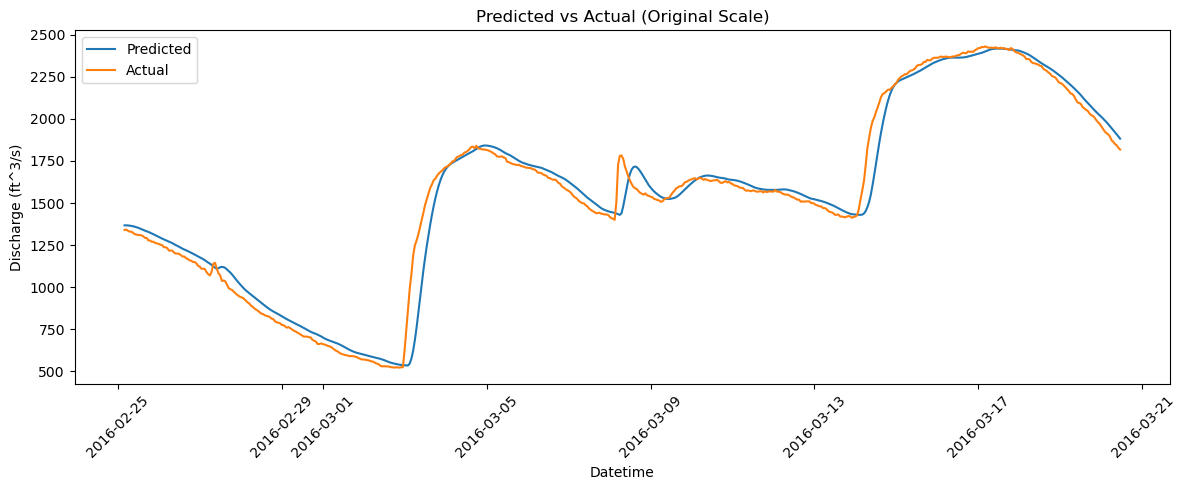

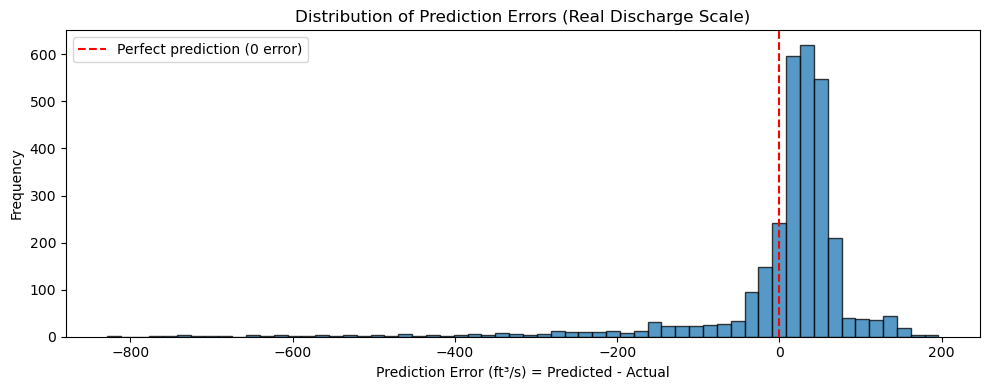

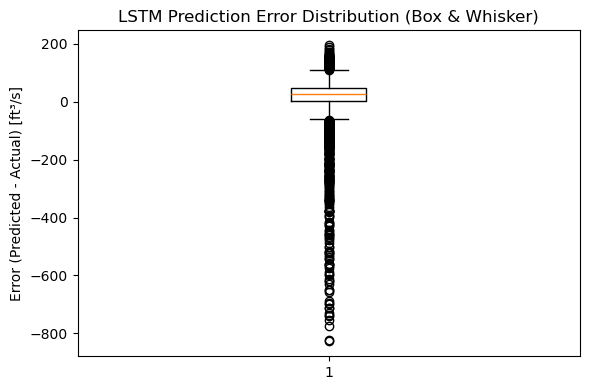

Q1: 3.7310333251953125
Median: 27.16876220703125
Q3: 46.85931396484375


In [86]:
# Convert predictions back into real flow from stanard scalered flow
train_predictions = model1.predict(X_train1)

train_predictions = train_predictions.reshape(-1, 1)
y_train_scaled = y_train1.reshape(-1, 1)

train_predictions_real = y_scaler.inverse_transform(train_predictions)
train_actuals_real = y_scaler.inverse_transform(y_train1)

train_predictions_real = train_predictions_real.flatten()
train_actuals_real = train_actuals_real.flatten()

train_index = df_combined_v2.index[WINDOW_SIZE:WINDOW_SIZE + len(train_predictions_real)]

train_results = pd.DataFrame({
    "Train Predictions": train_predictions_real,
    "Actuals": train_actuals_real
}, index=train_index)

# =========================
# USER CONTROLS (ZOOM WINDOW)
# =========================

print(train_results.index.min())
print(train_results.index.max())


start_date = train_results.index.min() + pd.Timedelta(hours=1300) # e.g. "2017-01-01 00:00:00"
end_date   = train_results.index.max() - pd.Timedelta(hours=1100) # e.g. "2017-01-04 00:00:00" 

# OPTIONAL: if user sets a range, filter the results
train_results_plot = train_results.copy()

if start_date is not None and end_date is not None:
    train_results_plot = train_results.loc[start_date:end_date]

# Plot

plt.figure(figsize=(12,5))

plt.plot(train_results_plot.index,
         train_results_plot["Train Predictions"],
         label="Predicted")

plt.plot(train_results_plot.index,
         train_results_plot["Actuals"],
         label="Actual")

plt.legend()
plt.xlabel("Datetime")
plt.ylabel("Discharge (ft^3/s)")
plt.title("Predicted vs Actual (Original Scale)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Plot Histogram of errors

errors = train_results["Train Predictions"] - train_results["Actuals"]
abs_errors = errors.abs()

# Histogram of predicted errors
plt.figure(figsize=(10,4))

plt.hist(errors, bins=60, edgecolor="black", alpha=0.75)

plt.axvline(0, color="red", linestyle="--", label="Perfect prediction (0 error)")

plt.xlabel("Prediction Error (ft³/s) = Predicted - Actual")
plt.ylabel("Frequency")
plt.title("Distribution of Prediction Errors (Real Discharge Scale)")
plt.legend()

plt.tight_layout()
plt.show()

# Box and whisker plot of errors
plt.figure(figsize=(6,4))

plt.boxplot(errors.dropna(), vert=True)

plt.title("LSTM Prediction Error Distribution (Box & Whisker)")
plt.ylabel("Error (Predicted - Actual) [ft³/s]")

plt.tight_layout()
plt.show()

q1 = errors.quantile(0.25)
median = errors.quantile(0.50)
q3 = errors.quantile(0.75)

print("Q1:", q1)
print("Median:", median)
print("Q3:", q3)



# Multivariate LSTM

(2974, 24, 13) (2974,)
(974, 24, 13) (974,)


/Users/afrahboateng/anaconda3/envs/aml/lib/python3.11/site-packages/keras/src/layers/core/input_layer.py:27: UserWarning: Argument `input_shape` is deprecated. Use `shape` instead.
  warnings.warn(


Model: "sequential_11"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_7 (LSTM)                   │ (None, 64)             │        19,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_22 (Dense)                │ (None, 8)              │           520 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_23 (Dense)                │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 20,497 (80.07 KB)

 Trainable params: 20,497 (80.07 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
93/93 - 5s - 51ms/step - loss: 0.8599 - root_mean_squared_error: 0.9273 - val_loss: 0.6053 - val_root_mean_squared_error: 0.7780
Epoch 2/10
93/93 - 1s - 16ms/step - loss: 0.3669 - root_mean_squared_error: 0.6057 - val_loss: 0.1516 - val_root_mean_squared_error: 0.3893
Epoch 3/10
93/93 - 1s - 15ms/step - loss: 0.1928 - root_mean_squared_error: 0.4391 - val_loss: 0.0855 - val_root_mean_squared_error: 0.2924
Epoch 4/10
93/93 - 1s - 15ms/step - loss: 0.1041 - root_mean_squared_error: 0.3226 - val_loss: 0.0767 - val_root_mean_squared_error: 0.2770
Epoch 5/10
93/93 - 1s - 16ms/step - loss: 0.0653 - root_mean_squared_error: 0.2555 - val_loss: 0.0690 - val_root_mean_squared_error: 0.2626
Epoch 6/10
93/93 - 2s - 18ms/step - loss: 0.0453 - root_mean_squared_error: 0.2129 - val_loss: 0.0620 - val_root_mean_squared_error: 0.2491
Epoch 7/10
93/93 - 1s - 15ms/step - loss: 0.0333 - root_mean_squared_error: 0.1825 - val_loss: 0.0572 - val_root_mean_squared_error: 0.2392
Epoch 8/10
93/93 - 1

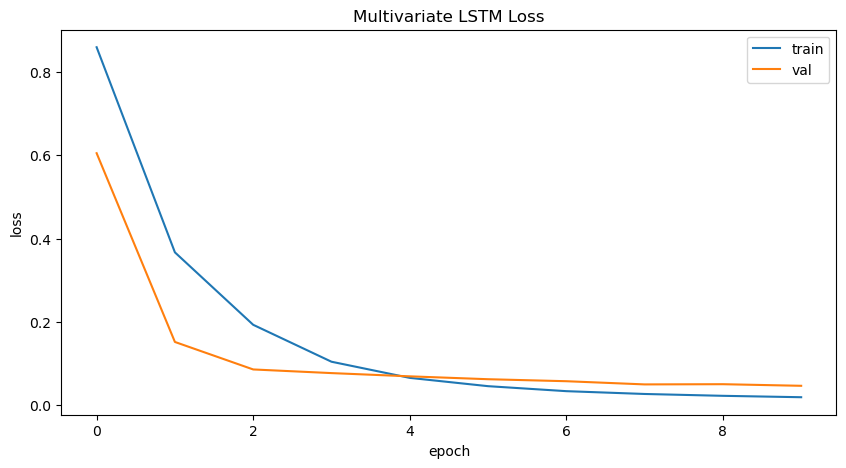

In [99]:
n_rows = 5000  # Set number of rows of data with which to build the model

# Set Target and input feature columns

target_col = "Discharge (ft^3/s)"

feature_cols = [
    # core flow
    "Discharge (ft^3/s)",

    # raw weather inputs
    "HourlyPrecipitation",
    "HourlyDryBulbTemperature",
    "HourlyDewPointTemperature",
    "HourlyRelativeHumidity",
    "HourlyStationPressure",
    "HourlyWindSpeed",

    # engineered lag features (VERY important)
    "flow_t-1h",
    "rain_t-6h",
    "temp_t-24h",

    # rolling features (captures storm accumulation)
    "rain_6h_sum",
    "rain_24h_sum",
    "flow_24h_avg"
]

df_model = df_combined_v2[feature_cols].copy()
df_model = df_model.tail(n_rows)
df_model = df_model.dropna()

# Scaling

# -------------------------
# SORT FIRST (VERY IMPORTANT for time series)
# -------------------------
df_model = df_model.sort_index()

# -------------------------
# SPLIT RATIOS
# -------------------------
train_size = int(len(df_model) * 0.6)
val_size = int(len(df_model) * 0.2)

train_data = df_model.iloc[:train_size]
val_data = df_model.iloc[train_size:train_size + val_size]
test_data = df_model.iloc[train_size + val_size:]

# Scaling

scaler = StandardScaler()

scaler.fit(train_data)

train_scaled = scaler.transform(train_data)
val_scaled = scaler.transform(val_data)
test_scaled = scaler.transform(test_data)

# Windowing Function (Fixed accross the many variables)

def df_to_X_y_multivariate(data, window_size=24, horizon=24, target_index=0, index=None):
    X = []
    y = []
    y_index = []

    for i in range(len(data) - window_size - horizon + 1):
        X.append(data[i:i+window_size])
        y.append(data[i + window_size + horizon - 1, target_index])

        # store timestamp of prediction point
        if index is not None:
            y_index.append(index[i + window_size + horizon - 1])

    return np.array(X), np.array(y), np.array(y_index)

# Create Sequences

WINDOW_SIZE = 24
HORIZON = 3

X_train, y_train, train_index = df_to_X_y_multivariate(
    train_scaled,
    WINDOW_SIZE,
    HORIZON,
    target_index=0,
    index=train_data.index.values
)

X_val, y_val, val_index = df_to_X_y_multivariate(
    val_scaled,
    WINDOW_SIZE,
    HORIZON,
    target_index=0,
    index=val_data.index.values
)

print(X_train.shape, y_train.shape)
print(X_val.shape, y_val.shape)

# LSTM model (UPDATED INPUT SHAPE)

model = Sequential()

model.add(InputLayer(input_shape=(WINDOW_SIZE, len(feature_cols))))
model.add(LSTM(64))
model.add(Dense(8, activation="relu"))
model.add(Dense(1, activation="linear"))

model.summary()

# Compile

cp = ModelCheckpoint("multivariate_lstm.keras", save_best_only=True)

model.compile(
    loss=MeanSquaredError(),
    optimizer=Adam(learning_rate=0.0001),
    metrics=[RootMeanSquaredError()]
)

# Train

history = model.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=10,
    batch_size=32,
    callbacks=[cp],
    verbose=2
)

# Loss Plot

plt.figure(figsize=(10,5))
plt.plot(history.history["loss"], label="train")
plt.plot(history.history["val_loss"], label="val")

plt.xlabel("epoch")
plt.ylabel("loss")
plt.title("Multivariate LSTM Loss")
plt.legend()
plt.show()


93/93 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step


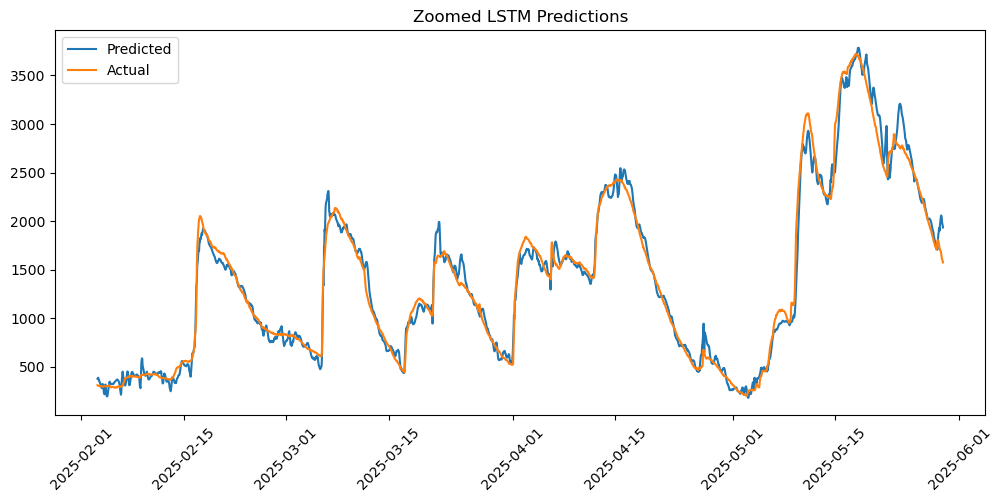

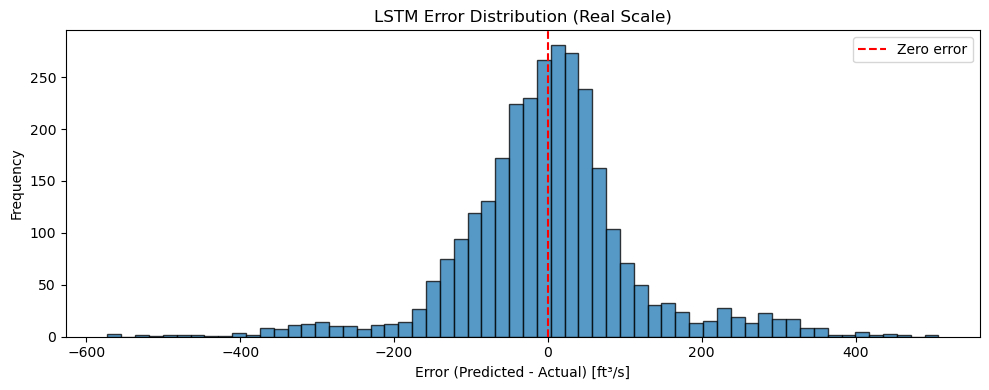

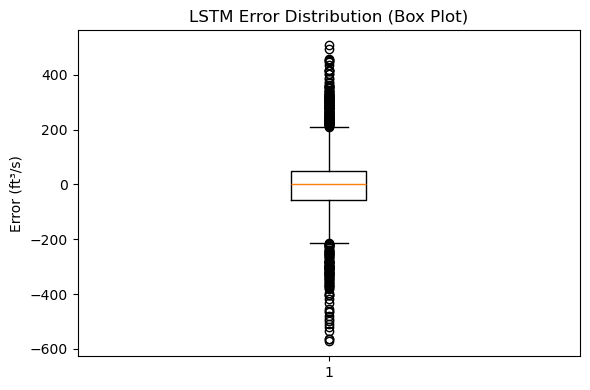

=== Error Summary ===
Q1 (25%): -55.98591860716593
Median  : 0.9314158100505665
Q3 (75%): 49.8466092796902


In [100]:
# Predictions vs Actuals Scaled

pred_scaled = model.predict(X_train).flatten()
y_train_flat = y_train.flatten()

def inverse_flow(scaled_values, scaler, target_index=0, n_features=len(feature_cols)):
    dummy = np.zeros((len(scaled_values), n_features))
    dummy[:, target_index] = scaled_values
    return scaler.inverse_transform(dummy)[:, target_index]

pred_real = inverse_flow(pred_scaled, scaler)
actual_real = inverse_flow(y_train_flat, scaler)

# Plot

train_results = pd.DataFrame({
    "predicted": pred_real,
    "actual": actual_real
}, index=train_index)

# default full range
start_date = train_results.index.min() + pd.Timedelta(hours=100)
end_date = train_results.index.max() - pd.Timedelta(hours=100)


zoom_df = train_results.loc[start_date:end_date]

plt.figure(figsize=(12,5))

plt.plot(zoom_df.index, zoom_df["predicted"], label="Predicted")
plt.plot(zoom_df.index, zoom_df["actual"], label="Actual")

plt.legend()
plt.title("Zoomed LSTM Predictions")
plt.xticks(rotation=45)

plt.show()

# Histogram of Errors

errors = pred_real - actual_real
abs_errors = np.abs(errors)

plt.figure(figsize=(10,4))

plt.hist(errors, bins=60, edgecolor="black", alpha=0.75)

plt.axvline(0, color="red", linestyle="--", label="Zero error")

plt.title("LSTM Error Distribution (Real Scale)")
plt.xlabel("Error (Predicted - Actual) [ft³/s]")
plt.ylabel("Frequency")
plt.legend()

plt.tight_layout()
plt.show()

#Boxplot

plt.figure(figsize=(6,4))

plt.boxplot(errors, vert=True)

plt.title("LSTM Error Distribution (Box Plot)")
plt.ylabel("Error (ft³/s)")

plt.tight_layout()
plt.show()

#Quartiles and Median

q1 = np.percentile(errors, 25)
median = np.percentile(errors, 50)
q3 = np.percentile(errors, 75)

print("=== Error Summary ===")
print("Q1 (25%):", q1)
print("Median  :", median)
print("Q3 (75%):", q3)